In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [38]:
df = pd.read_csv('/content/ispu_dki_all.csv')

In [39]:
df.columns = df.columns.str.lower().str.strip()

df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')

df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month
df['nama_bulan'] = df['tanggal'].dt.strftime('%B')

df['stasiun'] = df['stasiun'].astype(str).str.upper().str.strip()
df['categori'] = df['categori'].astype(str).str.upper().str.strip()
df['critical'] = df['critical'].astype(str).str.upper().str.strip()

Daftar stasiun:
<StringArray>
[  'DKI1 (BUNDERAN HI)', 'DKI2 (KELAPA GADING)',     'DKI3 (JAGAKARSA)',
  'DKI4 (LUBANG BUAYA)',   'DKI5 (KEBON JERUK)']
Length: 5, dtype: string

Jumlah data per stasiun:
stasiun
DKI4 (LUBANG BUAYA)     1674
DKI2 (KELAPA GADING)    1137
DKI3 (JAGAKARSA)        1116
DKI5 (KEBON JERUK)      1079
DKI1 (BUNDERAN HI)       531
Name: count, dtype: Int64


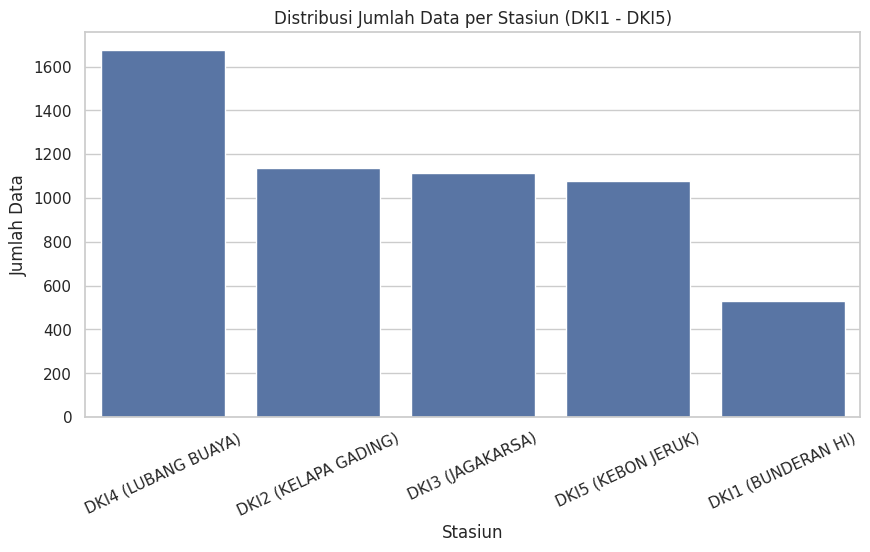

In [37]:
print("Daftar stasiun:")
print(df['stasiun'].unique())

print("\nJumlah data per stasiun:")
print(df['stasiun'].value_counts())

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='stasiun', order=df['stasiun'].value_counts().index)
plt.title("Distribusi Jumlah Data per Stasiun (DKI1 - DKI5)")
plt.xlabel("Stasiun")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=25)
plt.show()

In [41]:
missing_station = df.isna().groupby(df['stasiun']).sum()
display(missing_station)

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori,tahun,bulan,nama_bulan
stasiun,,,,,,,,,,,,,,
DKI1 (BUNDERAN HI),0,0,468,12,24,8,16,16,1,0,0,0,0,0
DKI2 (KELAPA GADING),0,0,958,22,11,7,1,3,0,0,0,0,0,0
DKI3 (JAGAKARSA),0,0,899,33,24,8,9,31,0,0,0,0,0,0
DKI4 (LUBANG BUAYA),0,0,816,195,28,39,70,36,0,0,0,0,0,0
DKI5 (KEBON JERUK),0,0,881,53,43,26,8,20,0,0,0,0,0,0
NAN,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Distribusi kategori per stasiun:


categori,BAIK,BERBAHAYA,SANGAT TIDAK SEHAT,SEDANG,TIDAK ADA DATA,TIDAK SEHAT
stasiun,,,,,,
DKI1 (BUNDERAN HI),143,0,0,355,4,29
DKI2 (KELAPA GADING),66,1,152,511,0,407
DKI3 (JAGAKARSA),38,0,9,758,0,311
DKI4 (LUBANG BUAYA),49,0,7,1009,0,609
DKI5 (KEBON JERUK),20,0,35,553,0,471


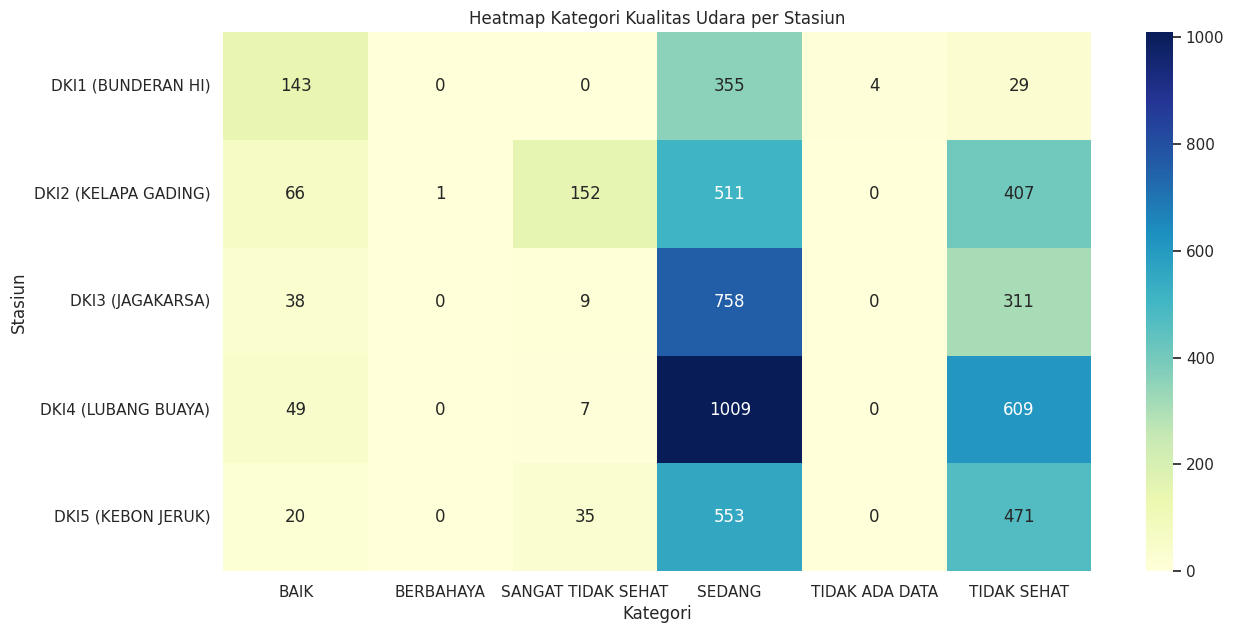

In [27]:
kategori_stasiun = pd.crosstab(df['stasiun'], df['categori'])

print("\nDistribusi kategori per stasiun:")
display(kategori_stasiun)

plt.figure(figsize=(14,7))
sns.heatmap(kategori_stasiun, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap Kategori Kualitas Udara per Stasiun")
plt.xlabel("Kategori")
plt.ylabel("Stasiun")
plt.show()


Polutan dominan per stasiun:


critical,O3,PM10,PM25,SO2
stasiun,,,,
DKI1 (BUNDERAN HI),106,109,295,21
DKI2 (KELAPA GADING),780,22,301,34
DKI3 (JAGAKARSA),676,13,405,22
DKI4 (LUBANG BUAYA),140,30,1500,4
DKI5 (KEBON JERUK),537,14,528,0


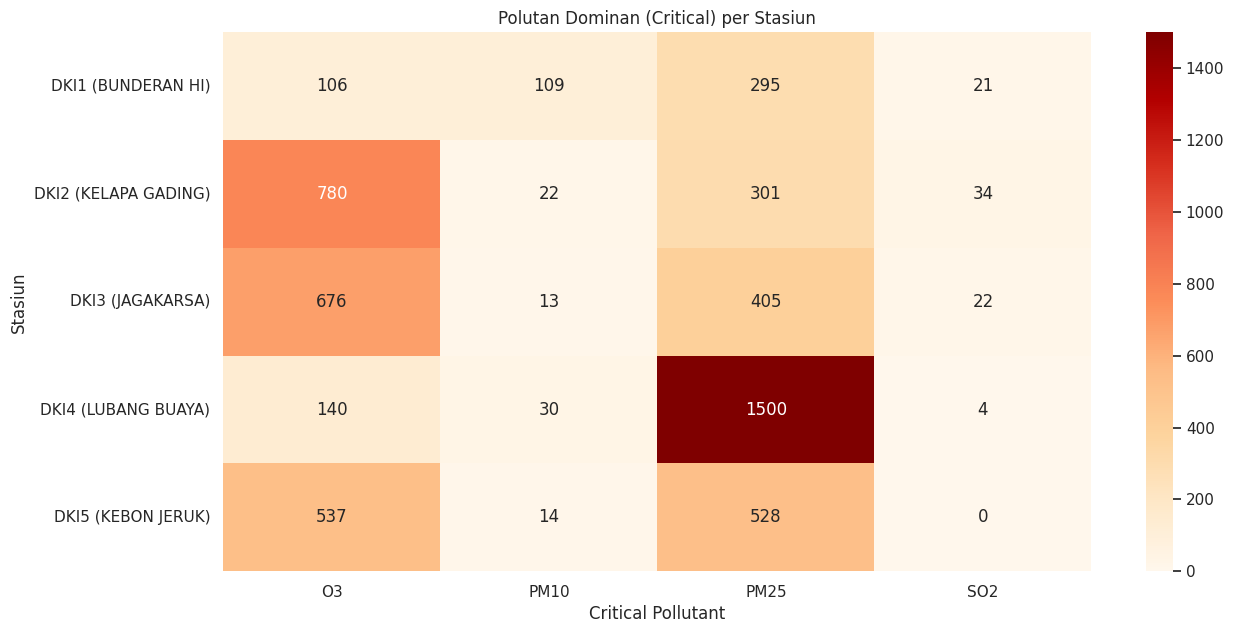

In [28]:
critical_station = pd.crosstab(df['stasiun'], df['critical'])

print("\nPolutan dominan per stasiun:")
display(critical_station)

plt.figure(figsize=(14,7))
sns.heatmap(critical_station, annot=True, fmt='d', cmap='OrRd')
plt.title("Polutan Dominan (Critical) per Stasiun")
plt.xlabel("Critical Pollutant")
plt.ylabel("Stasiun")
plt.show()


Rata-rata polutan per stasiun:


,pm25,pm10,so2,co,o3,no2,max
stasiun,,,,,,,
DKI1 (BUNDERAN HI),62.158192,50.984934,17.930320,29.584746,45.933145,17.367232,71.387947
DKI2 (KELAPA GADING),70.374670,54.792436,22.229991,19.290677,106.533861,15.783641,115.798593
DKI3 (JAGAKARSA),71.262545,46.112903,19.630824,18.188172,78.558692,10.250896,91.532706
DKI4 (LUBANG BUAYA),97.515532,66.998805,28.000896,17.225508,49.390980,15.591995,100.433094
DKI5 (KEBON JERUK),90.744208,55.270158,18.487952,22.262280,97.765524,10.653846,112.360519


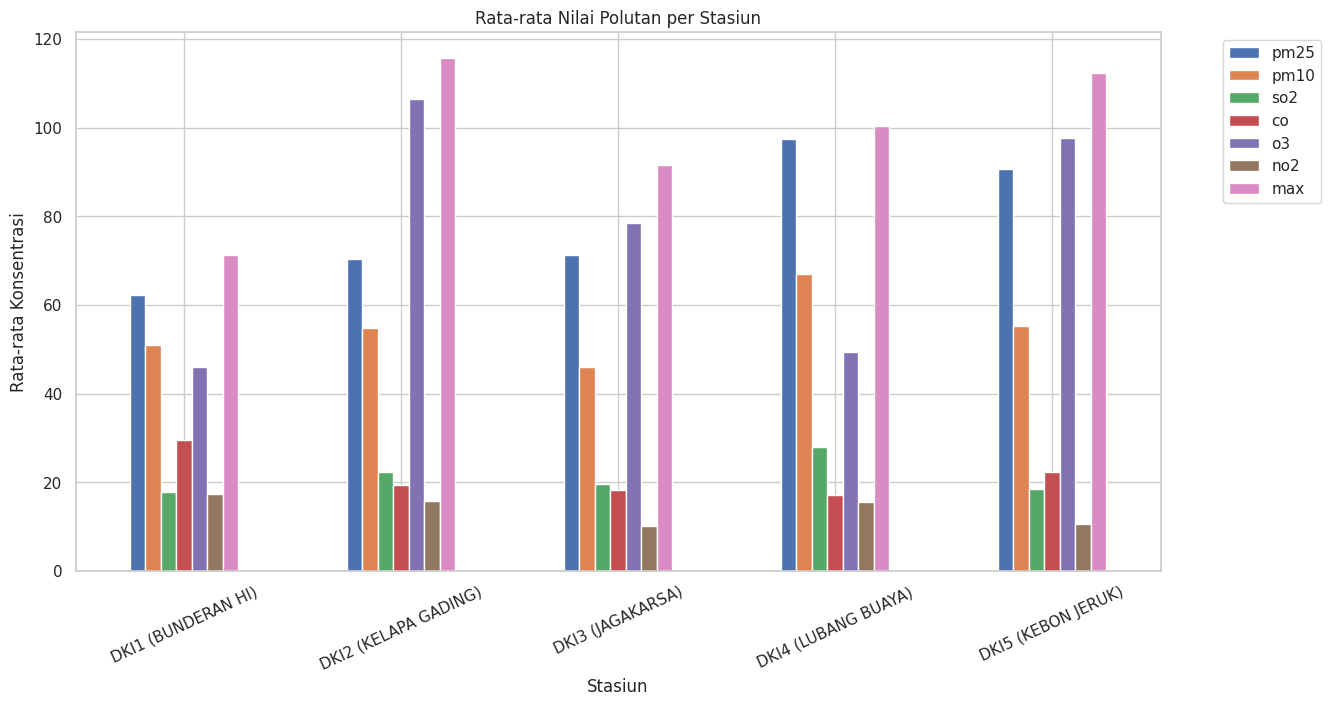

In [29]:
pollutant_cols = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'max']

avg_pollutant_station = df.groupby('stasiun')[pollutant_cols].mean()

print("\nRata-rata polutan per stasiun:")
display(avg_pollutant_station)

avg_pollutant_station.plot(kind='bar', figsize=(14,7))
plt.title("Rata-rata Nilai Polutan per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Rata-rata Konsentrasi")
plt.xticks(rotation=25)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

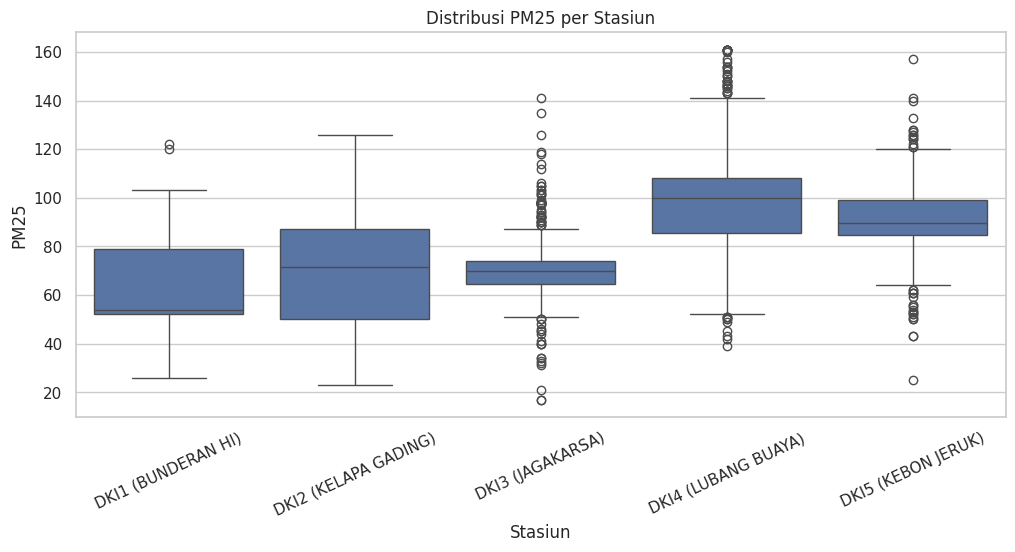

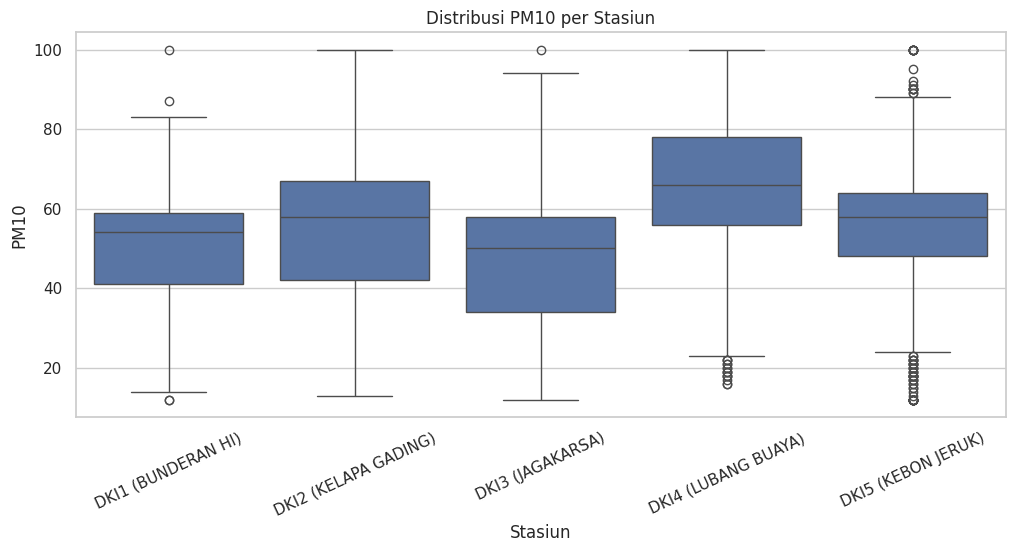

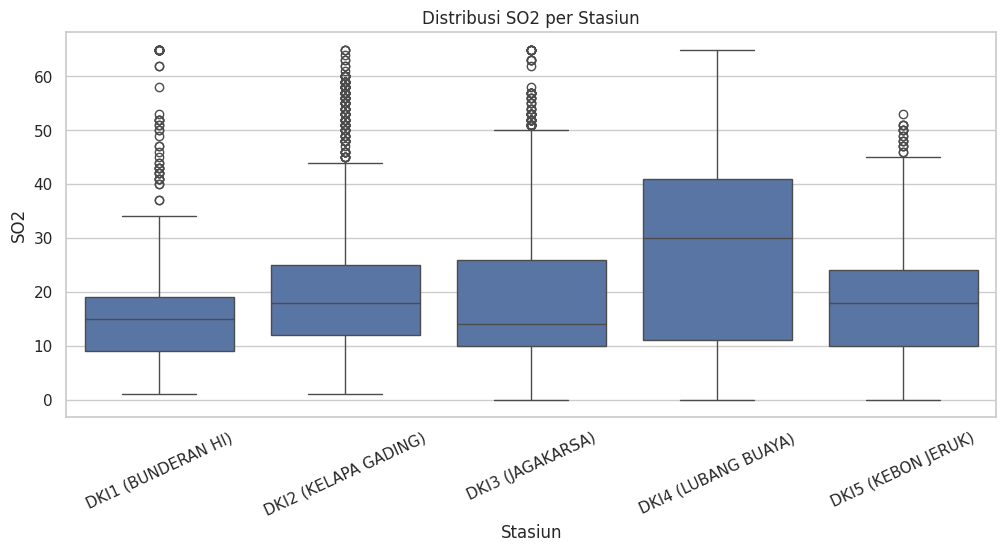

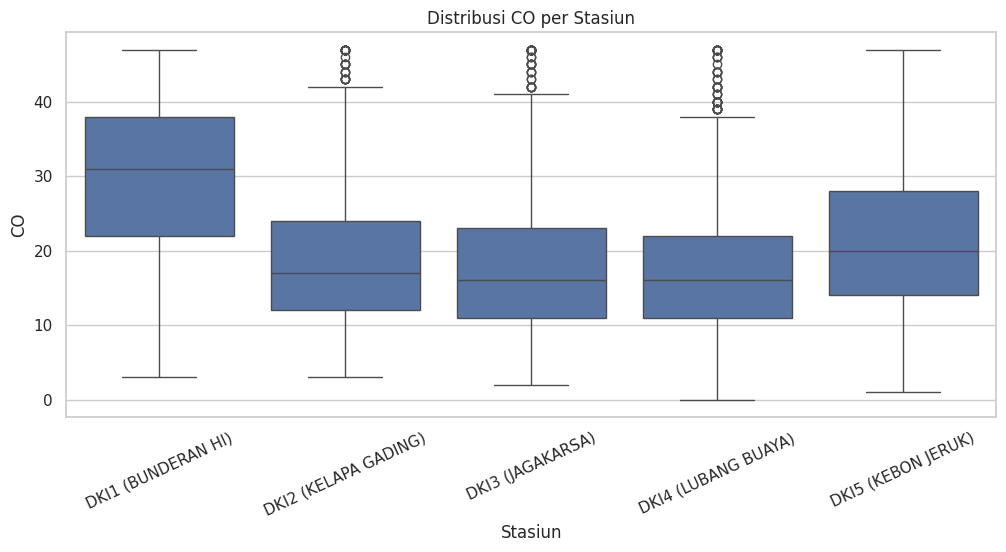

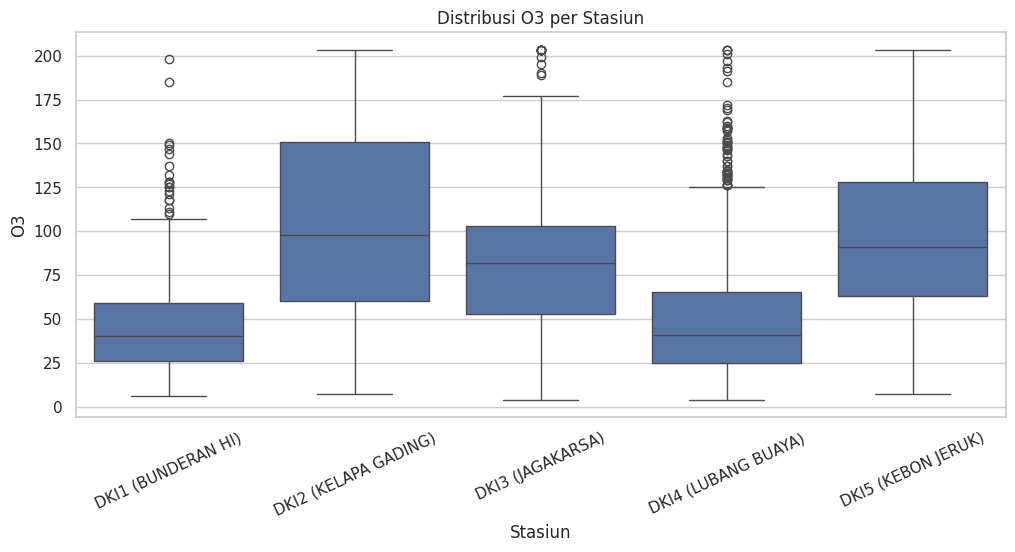

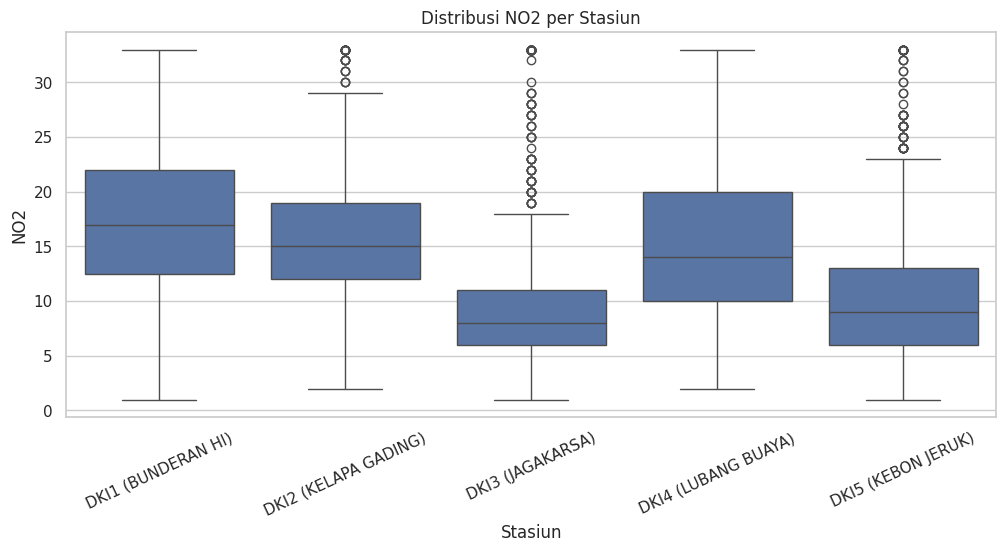

In [30]:
for col in ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']:
    plt.figure(figsize=(12,5))
    sns.boxplot(data=df, x='stasiun', y=col)
    plt.title(f"Distribusi {col.upper()} per Stasiun")
    plt.xlabel("Stasiun")
    plt.ylabel(col.upper())
    plt.xticks(rotation=25)
    plt.show()

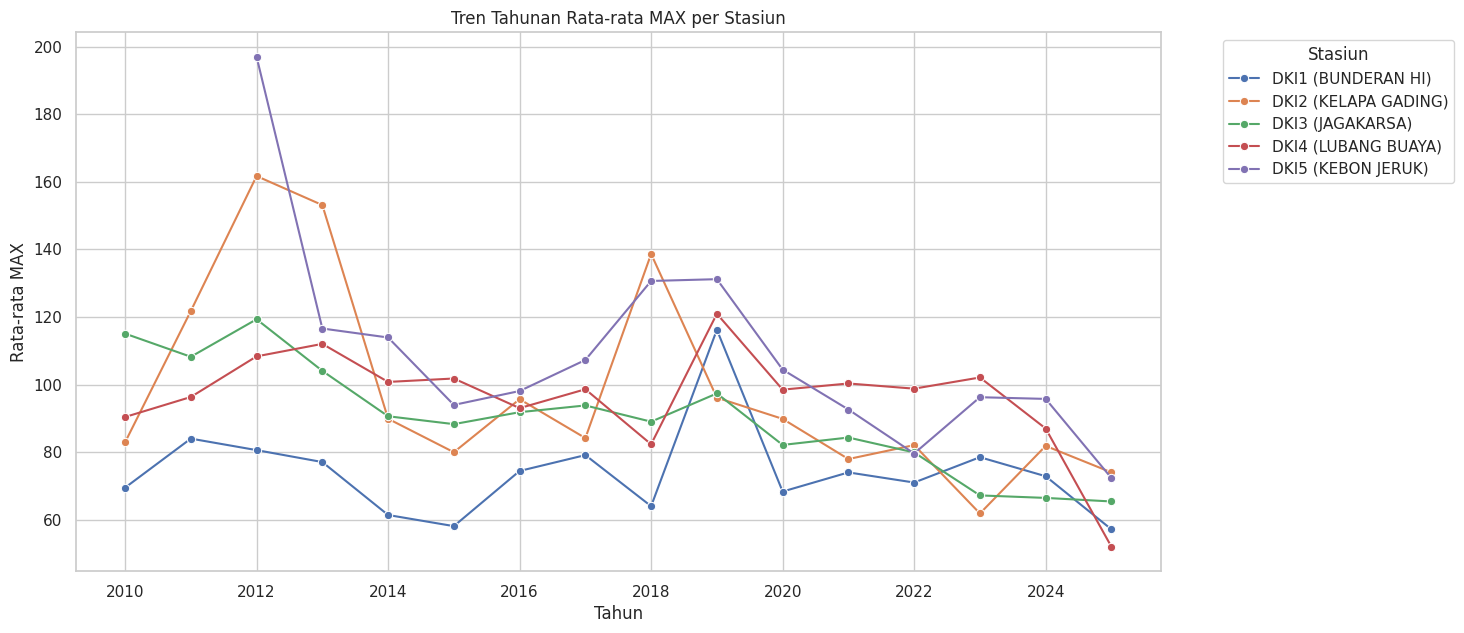

In [31]:
trend_station = df.groupby(['tahun', 'stasiun'])['max'].mean().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(data=trend_station, x='tahun', y='max', hue='stasiun', marker='o')
plt.title("Tren Tahunan Rata-rata MAX per Stasiun")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata MAX")
plt.legend(title='Stasiun', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

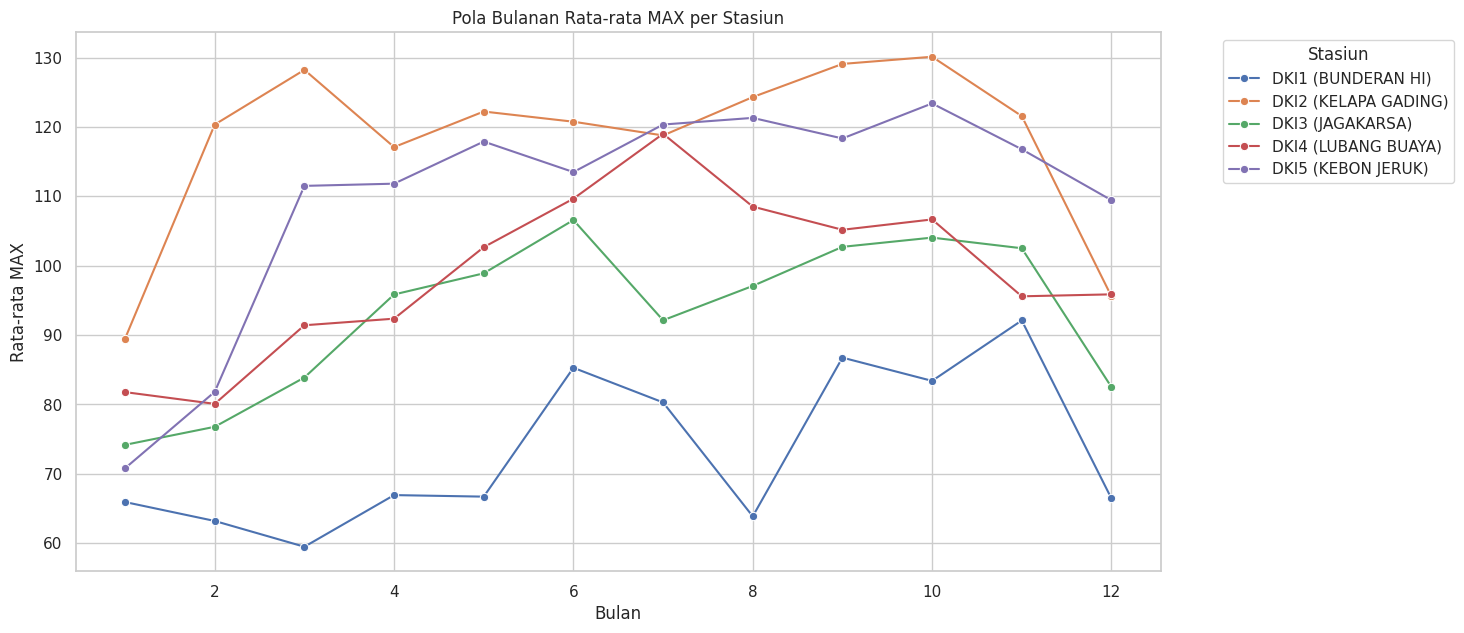

In [32]:
monthly_station = df.groupby(['bulan', 'stasiun'])['max'].mean().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(data=monthly_station, x='bulan', y='max', hue='stasiun', marker='o')
plt.title("Pola Bulanan Rata-rata MAX per Stasiun")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata MAX")
plt.legend(title='Stasiun', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

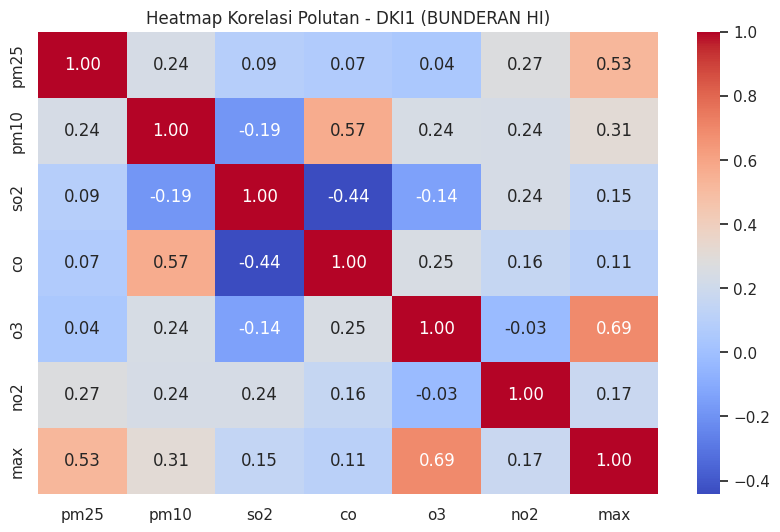

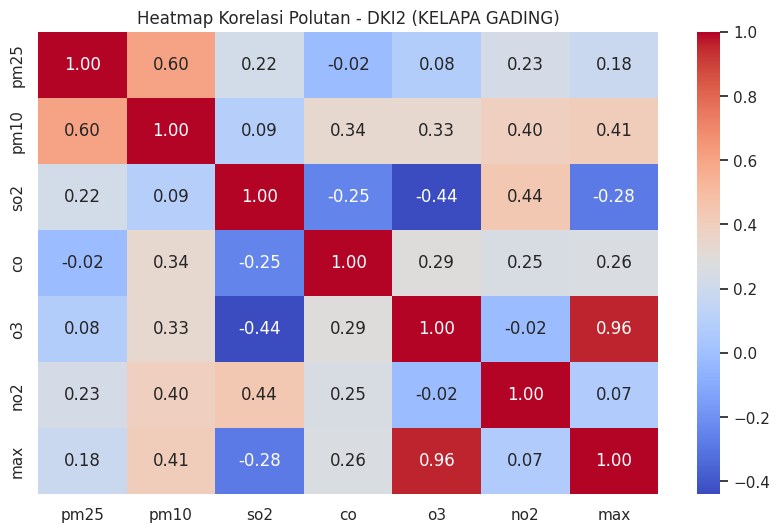

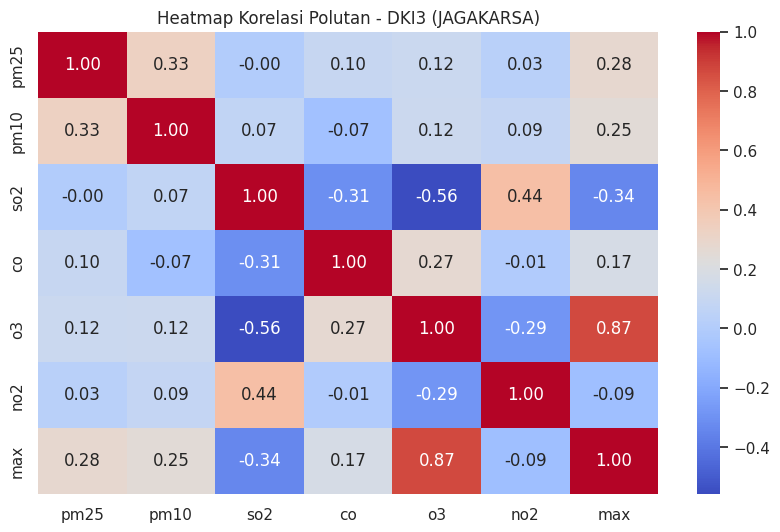

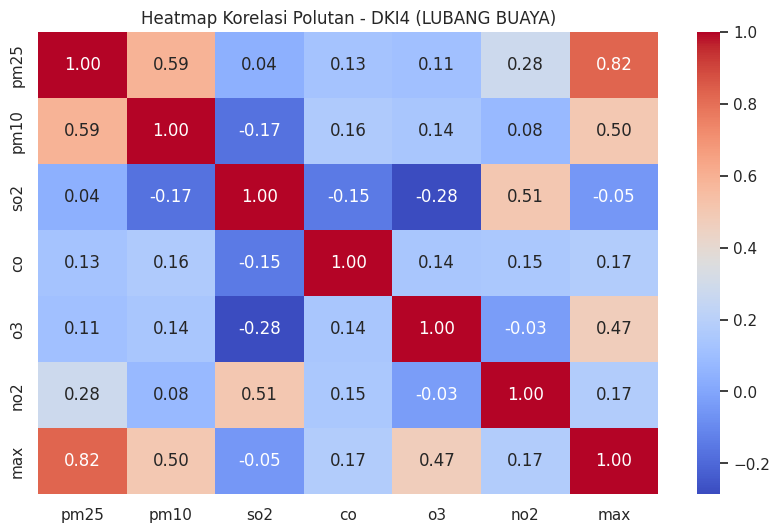

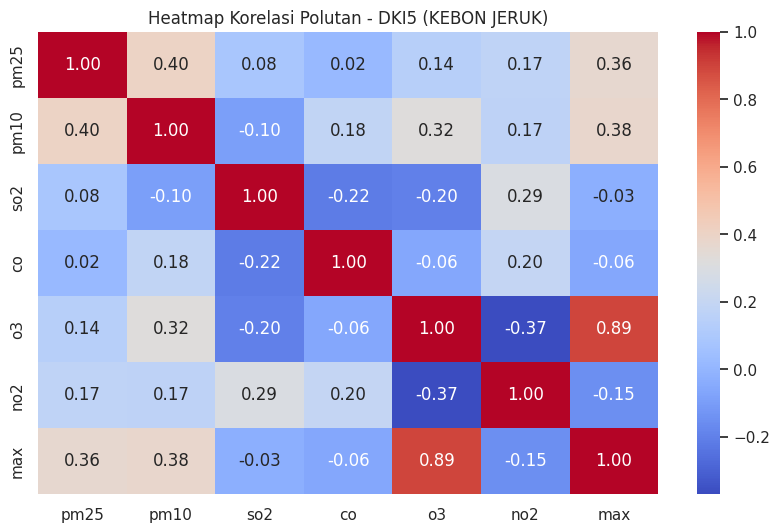

In [33]:
for station in df['stasiun'].dropna().unique():
    station_data = df[df['stasiun'] == station][pollutant_cols]

    plt.figure(figsize=(10,6))
    sns.heatmap(station_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f"Heatmap Korelasi Polutan - {station}")
    plt.show()

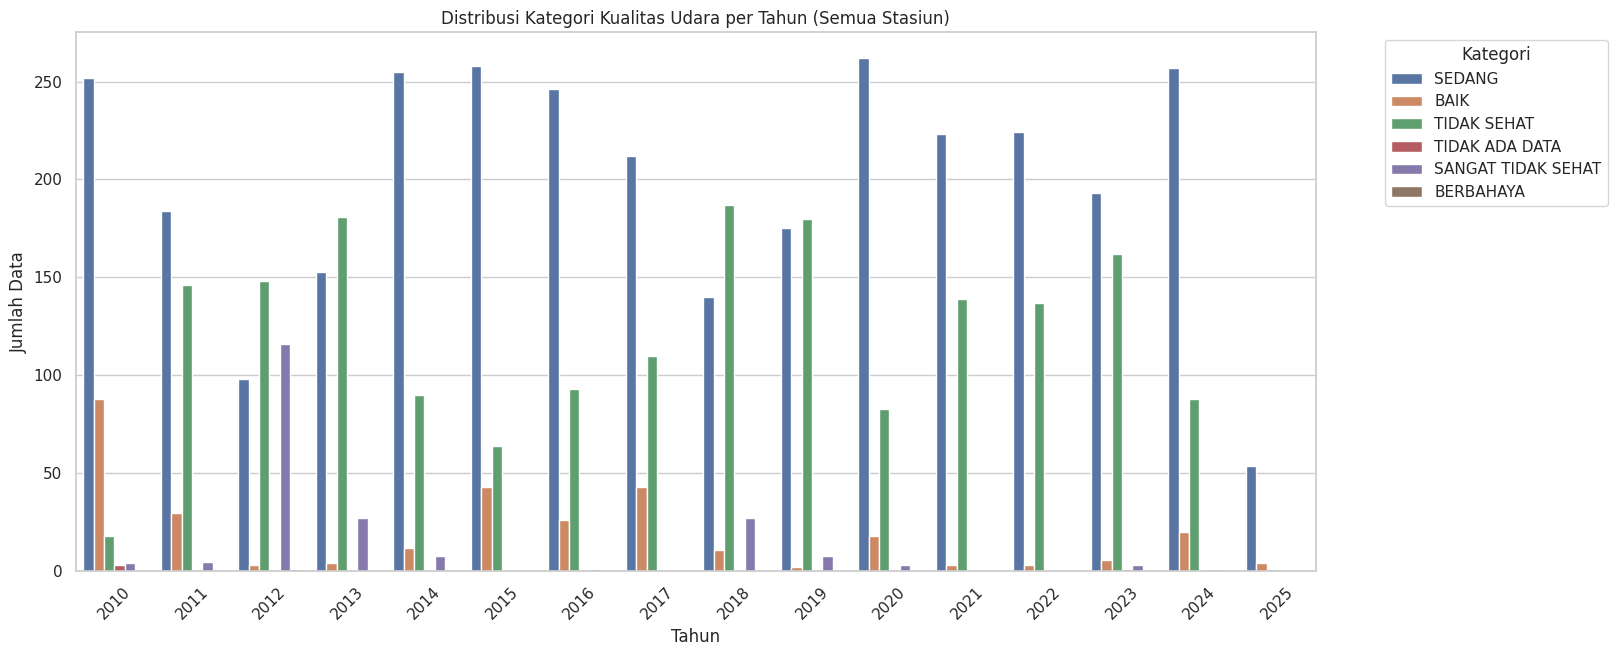

In [34]:
plt.figure(figsize=(16,7))
sns.countplot(data=df, x='tahun', hue='categori')
plt.title("Distribusi Kategori Kualitas Udara per Tahun (Semua Stasiun)")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.legend(title='Kategori', bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

In [35]:
print("\n===== RINGKASAN DATA =====")
print("Jumlah total data:", df.shape[0])
print("Jumlah stasiun:", df['stasiun'].nunique())
print("Rentang tahun:", df['tahun'].min(), "-", df['tahun'].max())

print("\nKategori terbanyak:")
print(df['categori'].value_counts())

print("\nCritical pollutant terbanyak:")
print(df['critical'].value_counts())


===== RINGKASAN DATA =====
Jumlah total data: 5537
Jumlah stasiun: 5
Rentang tahun: 2010 - 2025

Kategori terbanyak:
categori
SEDANG                3186
TIDAK SEHAT           1827
BAIK                   316
SANGAT TIDAK SEHAT     203
TIDAK ADA DATA           4
BERBAHAYA                1
Name: count, dtype: Int64

Critical pollutant terbanyak:
critical
PM25    3029
O3      2239
PM10     188
SO2       81
Name: count, dtype: Int64
